In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Function 1: Calculate distance between two points with two dimensions
def euclidean_distance(p1, p2):
    return np.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

# Function 2: Find neighbors within eps distance for one data point
def find_neighbors(data, point_idx, eps):
    neighbors = []
    for i in range(len(data)):
        if euclidean_distance(data[point_idx], data[i]) <= eps:
            neighbors.append(i)
    return neighbors # neighbors is the data index, not the true under value

# Function 3: Main DBSCAN algorithm
def dbscan(data, eps, min_pts):
    labels = [-1] * len(data)  # Start: all noise (as -1), each data point with one label
    cluster_id = 0 # start no cluster
    
    for i in range(len(data)):
        if labels[i] != -1:  # Already assigned
            continue # skips the rest of the current loop iteration and jumps to the next one.
        
        neighbors = find_neighbors(data, i, eps) # find neighbors for current point (i), each data point would calculate relationship with all data
        
        if len(neighbors) < min_pts:  # Not enough neighbors, so not core point
            continue # skips the rest of the current loop iteration and jumps to the next one.
        
        # Start new cluster
        labels[i] = cluster_id
        queue = neighbors.copy() # used to check 
        
        # Expand cluster
        while queue: # loop over current nerghbors, and check if it have been assigned cluster
            j = queue.pop(0) # j is the data index
            if labels[j] != -1: # Already assigned
                continue
            
            labels[j] = cluster_id # assign new cluster if it is -1
            neighbors_j = find_neighbors(data, j, eps) # check if point in the neighbor list
            if len(neighbors_j) >= min_pts: # if the neighbor is core point, add all of is neighboer to the current cluster
                queue.extend(neighbors_j)
        
        cluster_id += 1 # move to next cluster
    
    return labels

In [13]:
# Data points Example
X = np.array([
    [0, 0],      # Point 0 at (0, 0)
    [1, 1],      # Point 1 at (1, 1)
    [2, 2],      # Point 2 at (2, 2)
    [10, 10]     # Point 3 at (10, 10)
])

In [14]:
labels = dbscan(X, eps=2, min_pts=2)
print(f'Predicted Labels: {labels}')

Predicted Labels: [0, 0, 0, -1]


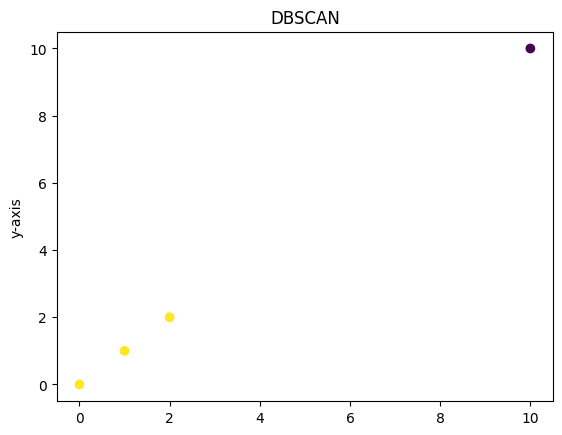

In [15]:
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.ylabel('X-axis')
plt.ylabel('y-axis')
plt.title('DBSCAN')
plt.show()